# CHAPTER 3. 금융거래 관계형 합성데이터 RAW 구조 점검

## 목적

MASK / HMAC / TOKEN 변환 실험에 앞서 원본 금융 데이터의 구조와 관계를 확인한다.

이번 단계에서는 데이터 정제나 변환을 수행하지 않는다.

확인 대상:
- 전체 CSV 파일
- 행/열 크기
- 컬럼명
- 결측치
- 중복값
- 고객 → 계좌 → 거래 관계에 사용되는 식별자

In [2]:
from pathlib import Path

import pandas as pd

# 01. 데이터 경로
DATA_DIR = Path(r"C:\Users\user\Desktop\uploaded to kaggle")

# 02. CSV 파일 목록 확인
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV 파일 수: {len(csv_files)}")

for file in csv_files:
    print(file.name)

CSV 파일 수: 11
account_statuses.csv
account_types.csv
accounts.csv
addresses.csv
branches.csv
customer_types.csv
customers.csv
loan_statuses.csv
loans.csv
transaction_types.csv
transactions.csv


In [3]:
# 01. 전체 CSV 로드
datasets = {}

for file in csv_files:
    df = pd.read_csv(file)
    datasets[file.stem] = df

# 02. 데이터 크기 확인
summary = []

for name, df in datasets.items():
    summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns)
    })

summary_df = pd.DataFrame(summary).sort_values("dataset")

summary_df

,dataset,rows,columns
0,account_statuses,3,2
1,account_types,5,2
2,accounts,1667,6
3,addresses,1222,4
4,branches,50,3
5,customer_types,3,2
6,customers,1111,6
7,loan_statuses,3,2
8,loans,333,7
9,transaction_types,4,2


In [4]:
for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print(f"shape: {df.shape}")
    print(df.columns.tolist())
    print()

account_statuses
shape: (3, 2)
['AccountStatusID', 'StatusName']

account_types
shape: (5, 2)
['AccountTypeID', 'TypeName']

accounts
shape: (1667, 6)
['AccountID', 'CustomerID', 'AccountTypeID', 'AccountStatusID', 'Balance', 'OpeningDate']

addresses
shape: (1222, 4)
['AddressID', 'Street', 'City', 'Country']

branches
shape: (50, 3)
['BranchID', 'BranchName', 'AddressID']

customer_types
shape: (3, 2)
['CustomerTypeID', 'TypeName']

customers
shape: (1111, 6)
['CustomerID', 'FirstName', 'LastName', 'DateOfBirth', 'AddressID', 'CustomerTypeID']

loan_statuses
shape: (3, 2)
['LoanStatusID', 'StatusName']

loans
shape: (333, 7)
['LoanID', 'AccountID', 'LoanStatusID', 'PrincipalAmount', 'InterestRate', 'StartDate', 'EstimatedEndDate']

transaction_types
shape: (4, 2)
['TransactionTypeID', 'TypeName']

transactions
shape: (50000, 8)
['TransactionID', 'AccountOriginID', 'AccountDestinationID', 'TransactionTypeID', 'Amount', 'TransactionDate', 'BranchID', 'Description']



In [5]:
# 01. 핵심 데이터 확인
core_tables = ["customers", "accounts", "transactions", "loans"]

for name in core_tables:
    if name in datasets:
        print("=" * 80)
        print(name)
        display(datasets[name].head())

customers


,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1
1,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2
2,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3
3,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1
4,10553,King,Becker,1966-02-20 00:00:00.000000,969,3


accounts


,AccountID,CustomerID,AccountTypeID,AccountStatusID,Balance,OpeningDate
0,200094,10123,3,1,48348.54,2018-06-12 00:00:00.000000
1,201108,10077,3,1,35001.41,2019-10-30 00:00:00.000000
2,201453,10321,3,2,57081.03,2020-05-24 00:00:00.000000
3,200581,10871,5,1,63164.33,2021-01-27 00:00:00.000000
4,200003,10765,1,1,58739.64,2018-09-12 00:00:00.000000


transactions


,TransactionID,AccountOriginID,AccountDestinationID,TransactionTypeID,Amount,TransactionDate,BranchID,Description
0,3022681,201164,200868,2,855.17,2023-04-20 02:00:00.000000,41,Transaction 22681
1,3037846,200138,201402,2,806.20,2021-08-10 15:00:00.000000,43,Transaction 37846
2,3045293,201002,201180,1,1229.44,2020-08-16 03:00:00.000000,5,Transaction 45293
3,3017397,201066,201144,4,4441.60,2021-10-10 06:00:00.000000,14,Transaction 17397
4,3016750,200289,201413,3,2526.20,2022-07-28 00:00:00.000000,37,Transaction 16750


loans


,LoanID,AccountID,LoanStatusID,PrincipalAmount,InterestRate,StartDate,EstimatedEndDate
0,400230,200876,1,76958.56,0.0547,2022-11-20 00:00:00.000000,2026-08-06 00:00:00.000000
1,400307,200789,1,29013.67,0.0321,2022-02-22 00:00:00.000000,2025-12-08 00:00:00.000000
2,400233,201275,1,48596.76,0.1017,2021-11-21 00:00:00.000000,2023-07-30 00:00:00.000000
3,400100,200070,1,9191.43,0.0999,2021-08-14 00:00:00.000000,2023-09-18 00:00:00.000000
4,400141,200808,1,76322.83,0.0906,2021-06-04 00:00:00.000000,2024-10-23 00:00:00.000000


# CHAPTER 2-1. 금융 관계형 데이터 정제

## 정제 순서

1. 중복값 제거
2. 이상값 점검 및 정제
3. 결측값 점검 및 정제
4. 정제 후 관계 무결성 검증
5. MASK / HMAC / TOKEN Utility 실험

## 중요 원칙

CustomerID, AccountID, TransactionID, LoanID 등 식별자는
숫자 크기가 크거나 작다는 이유로 이상값으로 판단하지 않는다.

이상값 검증은 실제 의미를 가지는 수치형 변수에만 적용한다.

예:
- Balance
- Amount
- PrincipalAmount
- InterestRate

날짜형 변수는 범위와 논리적 순서를 별도로 검증한다.

In [6]:
import pandas as pd

# 01. 핵심 데이터 복사
customers_clean = datasets["customers"].copy()
accounts_clean = datasets["accounts"].copy()
transactions_clean = datasets["transactions"].copy()
loans_clean = datasets["loans"].copy()

# 02. 전체 행 중복 확인
duplicate_summary = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "rows_before": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ],
    "full_row_duplicates": [
        customers_clean.duplicated().sum(),
        accounts_clean.duplicated().sum(),
        transactions_clean.duplicated().sum(),
        loans_clean.duplicated().sum()
    ]
})

duplicate_summary

,table,rows_before,full_row_duplicates
0,customers,1111,11
1,accounts,1667,16
2,transactions,50000,500
3,loans,333,3


In [7]:
# 01. Primary Key 중복 확인
pk_duplicate_summary = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "primary_key": [
        "CustomerID",
        "AccountID",
        "TransactionID",
        "LoanID"
    ],
    "pk_duplicates": [
        customers_clean["CustomerID"].duplicated().sum(),
        accounts_clean["AccountID"].duplicated().sum(),
        transactions_clean["TransactionID"].duplicated().sum(),
        loans_clean["LoanID"].duplicated().sum()
    ]
})

pk_duplicate_summary

,table,primary_key,pk_duplicates
0,customers,CustomerID,11
1,accounts,AccountID,16
2,transactions,TransactionID,500
3,loans,LoanID,3


In [9]:
# 01. 중복 제거 전후 비교
duplicate_cleaning_result = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "before": [
        len(datasets["customers"]),
        len(datasets["accounts"]),
        len(datasets["transactions"]),
        len(datasets["loans"])
    ],
    "after": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

# 02. 제거 건수
duplicate_cleaning_result["removed"] = (
    duplicate_cleaning_result["before"]
    - duplicate_cleaning_result["after"]
)

# 03. 제거율
duplicate_cleaning_result["removal_rate_pct"] = (
    duplicate_cleaning_result["removed"]
    / duplicate_cleaning_result["before"]
    * 100
).round(2)

duplicate_cleaning_result

,table,before,after,removed,removal_rate_pct
0,customers,1111,1100,11,0.99
1,accounts,1667,1651,16,0.96
2,transactions,50000,49500,500,1.00
3,loans,333,330,3,0.90


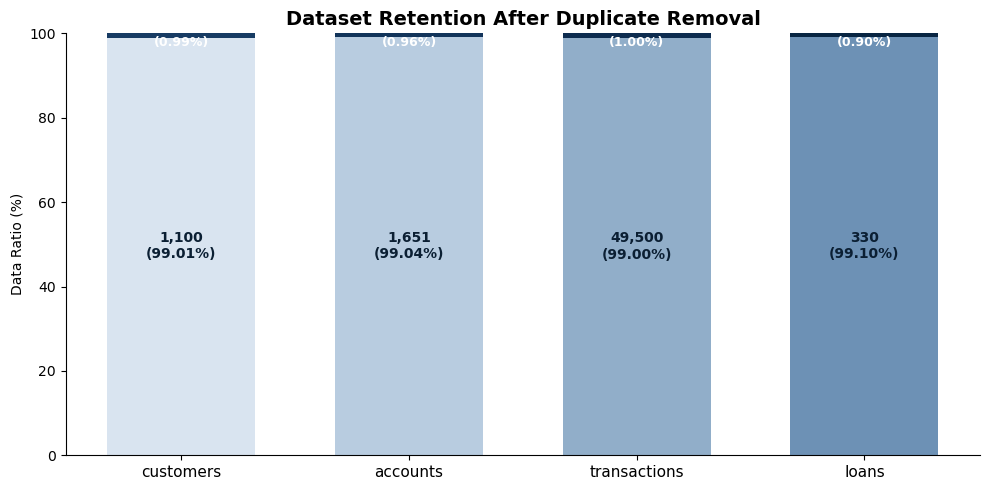

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 01. 비율 계산
plot_df = duplicate_cleaning_result.copy()

plot_df["remaining_rate_pct"] = (
    plot_df["after"] / plot_df["before"] * 100
)

plot_df["removed_rate_pct"] = (
    plot_df["removed"] / plot_df["before"] * 100
)

# 02. 딥네이비 팔레트
remaining_colors = [
    "#D9E4F0",
    "#B8CCE0",
    "#91AEC9",
    "#6D91B5"
]

removed_colors = [
    "#173B63",
    "#12345A",
    "#0D2C4F",
    "#082542"
]

# 03. 그래프
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(plot_df))

# 04. 남은 데이터
for i in range(len(plot_df)):
    ax.bar(
        x[i],
        plot_df.loc[i, "remaining_rate_pct"],
        color=remaining_colors[i],
        width=0.65
    )

# 05. 제거 데이터
for i in range(len(plot_df)):
    ax.bar(
        x[i],
        plot_df.loc[i, "removed_rate_pct"],
        bottom=plot_df.loc[i, "remaining_rate_pct"],
        color=removed_colors[i],
        width=0.65
    )

# 06. 남은 데이터 라벨
for i in range(len(plot_df)):
    remaining = plot_df.loc[i, "remaining_rate_pct"]
    after = plot_df.loc[i, "after"]

    ax.text(
        x[i],
        remaining / 2,
        f"{after:,}\n({remaining:.2f}%)",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#0B1F33"
    )

# 07. 제거 데이터 라벨
for i in range(len(plot_df)):
    remaining = plot_df.loc[i, "remaining_rate_pct"]
    removed_rate = plot_df.loc[i, "removed_rate_pct"]
    removed = plot_df.loc[i, "removed"]

    ax.text(
        x[i],
        remaining + removed_rate / 2,
        f"{removed:,}\n({removed_rate:.2f}%)",
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

# 08. 축 설정
ax.set_xticks(x)
ax.set_xticklabels(plot_df["table"], fontsize=11)

ax.set_ylim(0, 100)
ax.set_ylabel("Data Ratio (%)")
ax.set_xlabel("")
ax.set_title(
    "Dataset Retention After Duplicate Removal",
    fontsize=14,
    fontweight="bold"
)

# 09. 그래프 정리
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# 01. 테이블별 결측치 확인
tables = {
    "customers": customers_clean,
    "accounts": accounts_clean,
    "transactions": transactions_clean,
    "loans": loans_clean
}

missing_rows = []

for table_name, df in tables.items():

    for col in df.columns:

        missing_count = df[col].isna().sum()

        if missing_count > 0:

            missing_rows.append({
                "table": table_name,
                "column": col,
                "missing_count": missing_count,
                "total_rows": len(df),
                "missing_rate_pct": round(
                    missing_count / len(df) * 100, 2
                )
            })

missing_summary = (
    pd.DataFrame(missing_rows)
    .sort_values(
        ["table", "missing_rate_pct"],
        ascending=[True, False]
    )
)

missing_summary

,table,column,missing_count,total_rows,missing_rate_pct
3,accounts,OpeningDate,33,1651,2.00
2,customers,DateOfBirth,32,1100,2.91
0,customers,FirstName,22,1100,2.00
1,customers,LastName,22,1100,2.00
5,loans,StartDate,6,330,1.82
6,loans,EstimatedEndDate,6,330,1.82
4,transactions,TransactionDate,990,49500,2.00


In [19]:
# 01. 한 개 이상의 결측값을 가진 행 확인
missing_row_summary = []

for table_name, df in tables.items():

    missing_row_mask = df.isna().any(axis=1)

    missing_row_summary.append({
        "table": table_name,
        "total_rows": len(df),
        "rows_with_missing": missing_row_mask.sum(),
        "row_missing_rate_pct": round(
            missing_row_mask.mean() * 100, 2
        )
    })

missing_row_summary = pd.DataFrame(missing_row_summary)

missing_row_summary

,table,total_rows,rows_with_missing,row_missing_rate_pct
0,customers,1100,72,6.55
1,accounts,1651,33,2.00
2,transactions,49500,990,2.00
3,loans,330,12,3.64


In [20]:
# 01. 관계 및 업무 핵심 컬럼
critical_columns = {
    "customers": [
        "CustomerID"
    ],

    "accounts": [
        "AccountID",
        "CustomerID"
    ],

    "transactions": [
        "TransactionID",
        "AccountOriginID",
        "AccountDestinationID",
        "Amount",
        "TransactionDate"
    ],

    "loans": [
        "LoanID",
        "AccountID",
        "PrincipalAmount",
        "InterestRate",
        "StartDate",
        "EstimatedEndDate"
    ]
}

# 02. 핵심 컬럼 결측 진단
critical_missing_rows = []

for table_name, columns in critical_columns.items():

    df = tables[table_name]

    for col in columns:

        count = df[col].isna().sum()

        critical_missing_rows.append({
            "table": table_name,
            "column": col,
            "missing_count": count,
            "missing_rate_pct": round(
                count / len(df) * 100, 3
            )
        })

critical_missing_summary = pd.DataFrame(
    critical_missing_rows
)

critical_missing_summary

,table,column,missing_count,missing_rate_pct
0,customers,CustomerID,0,0.000
1,accounts,AccountID,0,0.000
2,accounts,CustomerID,0,0.000
3,transactions,TransactionID,0,0.000
4,transactions,AccountOriginID,0,0.000
5,transactions,AccountDestinationID,0,0.000
6,transactions,Amount,0,0.000
7,transactions,TransactionDate,990,2.000
8,loans,LoanID,0,0.000
9,loans,AccountID,0,0.000


In [21]:
# 01. 제거 전 건수
before_missing = {
    "customers": len(customers_clean),
    "accounts": len(accounts_clean),
    "transactions": len(transactions_clean),
    "loans": len(loans_clean)
}

# 02. 핵심 컬럼 결측 행 제거
customers_clean = customers_clean.dropna(
    subset=critical_columns["customers"]
).copy()

accounts_clean = accounts_clean.dropna(
    subset=critical_columns["accounts"]
).copy()

transactions_clean = transactions_clean.dropna(
    subset=critical_columns["transactions"]
).copy()

loans_clean = loans_clean.dropna(
    subset=critical_columns["loans"]
).copy()

# 03. 제거 결과
missing_cleaning_result = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "before": [
        before_missing["customers"],
        before_missing["accounts"],
        before_missing["transactions"],
        before_missing["loans"]
    ],
    "after": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

# 04. 제거 건수
missing_cleaning_result["removed"] = (
    missing_cleaning_result["before"]
    - missing_cleaning_result["after"]
)

# 05. 제거율
missing_cleaning_result["removal_rate_pct"] = (
    missing_cleaning_result["removed"]
    / missing_cleaning_result["before"]
    * 100
).round(3)

missing_cleaning_result

,table,before,after,removed,removal_rate_pct
0,customers,1100,1100,0,0.000
1,accounts,1651,1651,0,0.000
2,transactions,49500,48510,990,2.000
3,loans,330,318,12,3.636


# 금융 도메인 논리 이상값 정제

## 목적

통계적으로 값이 크다는 이유가 아니라,
금융 업무 및 데이터 논리상 성립할 수 없는 데이터를 탐지한다.

제거 기준:
- 미래 생년월일
- 미래 계좌 개설일
- 거래금액이 0 이하
- 미래 거래일
- 대출 원금이 0 이하
- 금리가 음수 또는 100% 이상
- 대출 종료예정일이 시작일보다 이전

제외 기준:
- 높은 거래금액
- 높은 대출원금
- 음수 계좌잔액

위 값들은 실제 금융업무에서 발생할 수 있으므로 자동 제거하지 않는다.

In [22]:
import pandas as pd

# 01. 날짜 타입 정리
customers_clean["DateOfBirth"] = pd.to_datetime(
    customers_clean["DateOfBirth"], errors="coerce"
)

accounts_clean["OpeningDate"] = pd.to_datetime(
    accounts_clean["OpeningDate"], errors="coerce"
)

transactions_clean["TransactionDate"] = pd.to_datetime(
    transactions_clean["TransactionDate"], errors="coerce"
)

loans_clean["StartDate"] = pd.to_datetime(
    loans_clean["StartDate"], errors="coerce"
)

loans_clean["EstimatedEndDate"] = pd.to_datetime(
    loans_clean["EstimatedEndDate"], errors="coerce"
)

# 02. 기준일
today = pd.Timestamp.today().normalize()

# 03. 규칙별 이상값
rules = {
    "Future DateOfBirth": (
        customers_clean["DateOfBirth"] > today
    ),

    "Future OpeningDate": (
        accounts_clean["OpeningDate"] > today
    ),

    "Amount <= 0": (
        transactions_clean["Amount"] <= 0
    ),

    "Future TransactionDate": (
        transactions_clean["TransactionDate"] > today
    ),

    "PrincipalAmount <= 0": (
        loans_clean["PrincipalAmount"] <= 0
    ),

    "InterestRate < 0": (
        loans_clean["InterestRate"] < 0
    ),

    "InterestRate >= 1": (
        loans_clean["InterestRate"] >= 1
    ),

    "EndDate < StartDate": (
        loans_clean["EstimatedEndDate"]
        < loans_clean["StartDate"]
    )
}

# 04. 지표 생성
logical_summary = []

for rule, mask in rules.items():

    count = int(mask.sum())

    if rule == "Future DateOfBirth":
        total = len(customers_clean)

    elif rule == "Future OpeningDate":
        total = len(accounts_clean)

    elif rule in ["Amount <= 0", "Future TransactionDate"]:
        total = len(transactions_clean)

    else:
        total = len(loans_clean)

    logical_summary.append({
        "rule": rule,
        "total_rows": total,
        "anomaly_rows": count,
        "anomaly_rate_pct": round(
            count / total * 100, 3
        )
    })

logical_summary = pd.DataFrame(logical_summary)

logical_summary

,rule,total_rows,anomaly_rows,anomaly_rate_pct
0,Future DateOfBirth,1100,0,0.000
1,Future OpeningDate,1651,0,0.000
2,Amount <= 0,48510,0,0.000
3,Future TransactionDate,48510,0,0.000
4,PrincipalAmount <= 0,318,0,0.000
5,InterestRate < 0,318,0,0.000
6,InterestRate >= 1,318,0,0.000
7,EndDate < StartDate,318,1,0.314


In [23]:
# 01. 거래 이상값
transaction_anomaly = (
    (transactions_clean["Amount"] <= 0)
    |
    (transactions_clean["TransactionDate"] > today)
)

display(
    transactions_clean.loc[transaction_anomaly]
)

# 02. 대출 이상값
loan_anomaly = (
    (loans_clean["PrincipalAmount"] <= 0)
    |
    (loans_clean["InterestRate"] < 0)
    |
    (loans_clean["InterestRate"] >= 1)
    |
    (
        loans_clean["EstimatedEndDate"]
        < loans_clean["StartDate"]
    )
)

display(
    loans_clean.loc[loan_anomaly]
)

,TransactionID,AccountOriginID,AccountDestinationID,TransactionTypeID,Amount,TransactionDate,BranchID,Description


,LoanID,AccountID,LoanStatusID,PrincipalAmount,InterestRate,StartDate,EstimatedEndDate
262,400080,201058,1,41196.54,0.1429,2026-03-18 15:01:44.338382,2024-05-30


In [24]:
# 01. 고객 이상값
customer_anomaly = (
    customers_clean["DateOfBirth"] > today
)

# 02. 계좌 이상값
account_anomaly = (
    accounts_clean["OpeningDate"] > today
)

# 03. 제거 전 건수
before_anomaly = {
    "customers": len(customers_clean),
    "accounts": len(accounts_clean),
    "transactions": len(transactions_clean),
    "loans": len(loans_clean)
}

# 04. 제거
customers_clean = customers_clean.loc[
    ~customer_anomaly
].copy()

accounts_clean = accounts_clean.loc[
    ~account_anomaly
].copy()

transactions_clean = transactions_clean.loc[
    ~transaction_anomaly
].copy()

loans_clean = loans_clean.loc[
    ~loan_anomaly
].copy()

# 05. 결과
anomaly_cleaning_result = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "before": [
        before_anomaly["customers"],
        before_anomaly["accounts"],
        before_anomaly["transactions"],
        before_anomaly["loans"]
    ],
    "after": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

anomaly_cleaning_result["removed"] = (
    anomaly_cleaning_result["before"]
    - anomaly_cleaning_result["after"]
)

anomaly_cleaning_result["removal_rate_pct"] = (
    anomaly_cleaning_result["removed"]
    / anomaly_cleaning_result["before"]
    * 100
).round(3)

anomaly_cleaning_result

,table,before,after,removed,removal_rate_pct
0,customers,1100,1100,0,0.000
1,accounts,1651,1651,0,0.000
2,transactions,48510,48510,0,0.000
3,loans,318,317,1,0.314


In [25]:
# 01. 기준일
today = pd.Timestamp.today().normalize()

# 02. 고객 이상값
customer_anomaly = (
    customers_clean["DateOfBirth"] > today
)

# 03. 계좌 이상값
account_anomaly = (
    accounts_clean["OpeningDate"] > today
)

# 04. 거래 이상값
transaction_anomaly = (
    (transactions_clean["Amount"] <= 0)
    |
    (transactions_clean["TransactionDate"] > today)
)

# 05. 대출 이상값
loan_anomaly = (
    (loans_clean["PrincipalAmount"] <= 0)
    |
    (loans_clean["InterestRate"] < 0)
    |
    (loans_clean["InterestRate"] >= 1)
    |
    (
        loans_clean["EstimatedEndDate"]
        < loans_clean["StartDate"]
    )
)

# 06. 제거 전 건수
before_anomaly = {
    "customers": len(customers_clean),
    "accounts": len(accounts_clean),
    "transactions": len(transactions_clean),
    "loans": len(loans_clean)
}

# 07. 이상값 제거
customers_clean = customers_clean.loc[
    ~customer_anomaly
].copy()

accounts_clean = accounts_clean.loc[
    ~account_anomaly
].copy()

transactions_clean = transactions_clean.loc[
    ~transaction_anomaly
].copy()

loans_clean = loans_clean.loc[
    ~loan_anomaly
].copy()

# 08. 제거 결과
anomaly_cleaning_result = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "before": [
        before_anomaly["customers"],
        before_anomaly["accounts"],
        before_anomaly["transactions"],
        before_anomaly["loans"]
    ],
    "after": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

# 09. 제거 건수
anomaly_cleaning_result["removed"] = (
    anomaly_cleaning_result["before"]
    - anomaly_cleaning_result["after"]
)

# 10. 제거율
anomaly_cleaning_result["removal_rate_pct"] = (
    anomaly_cleaning_result["removed"]
    / anomaly_cleaning_result["before"]
    * 100
).round(3)

anomaly_cleaning_result

,table,before,after,removed,removal_rate_pct
0,customers,1100,1100,0,0.0
1,accounts,1651,1651,0,0.0
2,transactions,48510,48510,0,0.0
3,loans,317,317,0,0.0


# 금융 데이터 관계 무결성 검증

## 목적

정제된 데이터에서 고객 → 계좌 → 거래 → 대출 관계가
실제로 정상적으로 연결되는지 검증한다.

검증 관계:

- customers.CustomerID → accounts.CustomerID
- accounts.AccountID → transactions.AccountOriginID
- accounts.AccountID → transactions.AccountDestinationID
- accounts.AccountID → loans.AccountID

존재하지 않는 부모 키를 참조하는 레코드는
고아 레코드(Orphan Record)로 분류하여 제거한다.

In [26]:
# 01. Customer → Account
invalid_account = ~accounts_clean["CustomerID"].isin(
    customers_clean["CustomerID"]
)

# 02. Account → Transaction Origin
invalid_origin = ~transactions_clean["AccountOriginID"].isin(
    accounts_clean["AccountID"]
)

# 03. Account → Transaction Destination
invalid_destination = ~transactions_clean["AccountDestinationID"].isin(
    accounts_clean["AccountID"]
)

# 04. Account → Loan
invalid_loan = ~loans_clean["AccountID"].isin(
    accounts_clean["AccountID"]
)

# 05. 관계 무결성 지표
fk_summary = pd.DataFrame({
    "relationship": [
        "Customer → Account",
        "Account → Transaction Origin",
        "Account → Transaction Destination",
        "Account → Loan"
    ],
    "total_rows": [
        len(accounts_clean),
        len(transactions_clean),
        len(transactions_clean),
        len(loans_clean)
    ],
    "invalid_rows": [
        invalid_account.sum(),
        invalid_origin.sum(),
        invalid_destination.sum(),
        invalid_loan.sum()
    ]
})

fk_summary["invalid_rate_pct"] = (
    fk_summary["invalid_rows"]
    / fk_summary["total_rows"]
    * 100
).round(3)

fk_summary["integrity_rate_pct"] = (
    100 - fk_summary["invalid_rate_pct"]
).round(3)

fk_summary

,relationship,total_rows,invalid_rows,invalid_rate_pct,integrity_rate_pct
0,Customer → Account,1651,0,0.0,100.0
1,Account → Transaction Origin,48510,0,0.0,100.0
2,Account → Transaction Destination,48510,0,0.0,100.0
3,Account → Loan,317,0,0.0,100.0


In [27]:
# 01. 제거 전 건수
before_fk = {
    "customers": len(customers_clean),
    "accounts": len(accounts_clean),
    "transactions": len(transactions_clean),
    "loans": len(loans_clean)
}

# 02. 잘못된 고객을 참조하는 계좌 제거
accounts_clean = accounts_clean[
    accounts_clean["CustomerID"].isin(
        customers_clean["CustomerID"]
    )
].copy()

# 03. 계좌 제거 후 거래 관계 다시 검증
valid_accounts = set(accounts_clean["AccountID"])

transactions_clean = transactions_clean[
    transactions_clean["AccountOriginID"].isin(valid_accounts)
    &
    transactions_clean["AccountDestinationID"].isin(valid_accounts)
].copy()

# 04. 대출 관계 정제
loans_clean = loans_clean[
    loans_clean["AccountID"].isin(valid_accounts)
].copy()

# 05. 결과
fk_cleaning_result = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],
    "before": [
        before_fk["customers"],
        before_fk["accounts"],
        before_fk["transactions"],
        before_fk["loans"]
    ],
    "after": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

fk_cleaning_result["removed"] = (
    fk_cleaning_result["before"]
    - fk_cleaning_result["after"]
)

fk_cleaning_result["removal_rate_pct"] = (
    fk_cleaning_result["removed"]
    / fk_cleaning_result["before"]
    * 100
).round(3)

fk_cleaning_result

,table,before,after,removed,removal_rate_pct
0,customers,1100,1100,0,0.0
1,accounts,1651,1651,0,0.0
2,transactions,48510,48510,0,0.0
3,loans,317,317,0,0.0


In [28]:
# 01. 전체 정제 단계 요약
cleaning_final = pd.DataFrame({
    "table": [
        "customers",
        "accounts",
        "transactions",
        "loans"
    ],

    "original": [
        1111,
        1667,
        50000,
        333
    ],

    "duplicate_removed": [
        11,
        16,
        500,
        3
    ],

    "missing_removed": [
        0,
        0,
        990,
        12
    ],

    "anomaly_removed": [
        0,
        0,
        0,
        1
    ],

    "fk_removed": [
        0,
        0,
        0,
        0
    ],

    "remaining": [
        len(customers_clean),
        len(accounts_clean),
        len(transactions_clean),
        len(loans_clean)
    ]
})

# 02. 최종 잔존율
cleaning_final["remaining_rate_pct"] = (
    cleaning_final["remaining"]
    / cleaning_final["original"]
    * 100
).round(2)

# 03. 전체 제거율
cleaning_final["total_removed"] = (
    cleaning_final["original"]
    - cleaning_final["remaining"]
)

cleaning_final["total_removal_rate_pct"] = (
    cleaning_final["total_removed"]
    / cleaning_final["original"]
    * 100
).round(2)

cleaning_final

,table,original,duplicate_removed,missing_removed,anomaly_removed,fk_removed,remaining,remaining_rate_pct,total_removed,total_removal_rate_pct
0,customers,1111,11,0,0,0,1100,99.01,11,0.99
1,accounts,1667,16,0,0,0,1651,99.04,16,0.96
2,transactions,50000,500,990,0,0,48510,97.02,1490,2.98
3,loans,333,3,12,1,0,317,95.20,16,4.80


In [29]:
# 01. Clean Baseline 고정
customers_base = customers_clean.copy(deep=True)
accounts_base = accounts_clean.copy(deep=True)
transactions_base = transactions_clean.copy(deep=True)
loans_base = loans_clean.copy(deep=True)

# 02. 최종 크기 확인
print("customers     :", customers_base.shape)
print("accounts      :", accounts_base.shape)
print("transactions  :", transactions_base.shape)
print("loans         :", loans_base.shape)

customers     : (1100, 6)
accounts      : (1651, 6)
transactions  : (48510, 8)
loans         : (317, 7)


# CHAPTER 2-6. 금융 관계형 데이터 최종 정제 결과

## 1. 최종 정제 결과

| Table | Original | Duplicate Removed | Missing Removed | Anomaly Removed | FK Removed | Remaining | Remaining Rate | Total Removed | Total Removal Rate |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| customers | 1,111 | 11 | 0 | 0 | 0 | 1,100 | 99.01% | 11 | 0.99% |
| accounts | 1,667 | 16 | 0 | 0 | 0 | 1,651 | 99.04% | 16 | 0.96% |
| transactions | 50,000 | 500 | 990 | 0 | 0 | 48,510 | 97.02% | 1,490 | 2.98% |
| loans | 333 | 3 | 12 | 1 | 0 | 317 | 95.20% | 16 | 4.80% |

---

## 2. 정제 결과 해석

- `customers`는 **1,111건 중 중복 11건(0.99%)**을 제거하여 **1,100건(99.01%)**을 최종 유지하였다.

- `accounts`는 **1,667건 중 중복 16건(0.96%)**을 제거하여 **1,651건(99.04%)**을 최종 유지하였다.

- `transactions`는 **50,000건 중 중복 500건(1.00%)**, 핵심 컬럼 결측 990건(1.98%)을 제거하였다.  
  총 **1,490건(2.98%)**이 제거되어 **48,510건(97.02%)**을 최종 유지하였다.

- `loans`는 **333건 중 중복 3건(0.90%)**, 핵심 컬럼 결측 12건(3.60%), 논리적 이상값 1건(0.30%)을 제거하였다.  
  총 **16건(4.80%)**이 제거되어 **317건(95.20%)**을 최종 유지하였다.

- Customer → Account → Transaction → Loan 관계에 대한 FK 검증 결과, **관계 위반 레코드는 0건(0.00%)**으로 확인되었다.

---

## 3. 논리적 이상값 상세

`loans`에서 확인된 논리적 이상값은 1건이다.

- `LoanID`: **400080**
- `AccountID`: **201058**
- `PrincipalAmount`: **41,196.54**
- `InterestRate`: **0.1429**
- `StartDate`: **2026-03-18 15:01:44**
- `EstimatedEndDate`: **2024-05-30**

해당 데이터는 대출 종료예정일이 시작일보다 **657일 앞서 있는 날짜 역전 오류**이다.

대출 데이터는 기본적으로 다음 시간 관계가 성립해야 한다.

> `StartDate < EstimatedEndDate`

그러나 해당 레코드는

> `EstimatedEndDate < StartDate`

로 기록되어 있어 실제 대출 기간의 시간 순서가 성립하지 않는다.

따라서 금액이나 금리가 크다는 이유가 아니라, **금융 업무상 성립할 수 없는 날짜 관계 오류**로 판단하여 제거하였다.

---

## 4. 최종 판단

정제 후 데이터 잔존율은 다음과 같다.

- `customers`: **99.01%**
- `accounts`: **99.04%**
- `transactions`: **97.02%**
- `loans`: **95.20%**

전체 데이터의 약 **95~99%를 유지**하면서 중복, 핵심 결측, 논리 오류를 제거하였다.

또한 Customer → Account → Transaction → Loan 관계에서 **FK 무결성 100%**가 확인되어, 정제 이후에도 금융 관계형 데이터 구조가 정상적으로 유지되었다.

따라서 현재 정제 데이터를 **Clean Baseline**으로 고정하고, 동일한 데이터에 MASK / HMAC / TOKEN 변환을 적용하여 변환 방식별 Utility를 비교한다.

다음 분석의 핵심 질문은 다음과 같다.

> **식별자를 보호한 이후에도 고객 → 계좌 → 거래 관계를 원본과 동일하게 추적할 수 있는가?**

# CHAPTER 2-7. MASK / HMAC / TOKEN Transform 적용

## 분석 목적

정제된 동일 금융 관계형 데이터에 MASK / HMAC / TOKEN을 적용한 뒤
고객 → 계좌 → 거래 → 대출 관계가 얼마나 유지되는지 비교한다.

모든 Transform은 동일한 Clean Baseline에서 시작한다.

## Transform 대상

### Customer 관계키
- customers.CustomerID
- accounts.CustomerID

### Account 관계키
- accounts.AccountID
- transactions.AccountOriginID
- transactions.AccountDestinationID
- loans.AccountID

## 비교 방식

### RAW
변환하지 않은 Clean Baseline

### MASK
식별자의 일부를 제거하여 직접 식별 가능성을 낮춘다.
단, 서로 다른 원본 값이 동일한 MASK 값으로 합쳐질 수 있으므로
관계 손실과 Collision 가능성이 존재한다.

### HMAC
동일한 원본 값에 대해 동일한 HMAC 값을 생성한다.
원문을 직접 노출하지 않으면서 데이터 간 동일성 비교가 가능하다.

### TOKEN
각 원본 식별자에 고유 Token을 부여한다.
동일 원본에는 동일 Token을 적용하며 Vault Mapping을 별도로 유지한다.

## 핵심 평가 질문

> Transform 이후에도 동일 고객·계좌·거래 관계를 정확하게 추적할 수 있는가?

In [30]:
import hashlib
import hmac
import secrets

# 01. HMAC Secret
HMAC_SECRET = b"fpg-experiment-secret-key"

# 02. MASK
def mask_id(value):
    if pd.isna(value):
        return value

    value = str(int(value))

    # 마지막 2자리만 유지
    if len(value) <= 2:
        return "*" * len(value)

    return "*" * (len(value) - 2) + value[-2:]


# 03. HMAC
def hmac_id(value):
    if pd.isna(value):
        return value

    value = str(int(value))

    return hmac.new(
        HMAC_SECRET,
        value.encode("utf-8"),
        hashlib.sha256
    ).hexdigest()[:16]

In [31]:
# 01. Customer Token Vault
customer_ids = sorted(
    customers_base["CustomerID"]
    .dropna()
    .astype(int)
    .unique()
)

customer_token_vault = {
    customer_id: f"CUST_{secrets.token_hex(6)}"
    for customer_id in customer_ids
}

# 02. Account Token Vault
account_ids = sorted(
    accounts_base["AccountID"]
    .dropna()
    .astype(int)
    .unique()
)

account_token_vault = {
    account_id: f"ACCT_{secrets.token_hex(6)}"
    for account_id in account_ids
}

print("Customer Tokens:", len(customer_token_vault))
print("Account Tokens :", len(account_token_vault))

Customer Tokens: 1100
Account Tokens : 1651


In [32]:
# 01. MASK 복제
customers_mask = customers_base.copy()
accounts_mask = accounts_base.copy()
transactions_mask = transactions_base.copy()
loans_mask = loans_base.copy()

# 02. CustomerID MASK
customers_mask["CustomerID"] = (
    customers_mask["CustomerID"].apply(mask_id)
)

accounts_mask["CustomerID"] = (
    accounts_mask["CustomerID"].apply(mask_id)
)

# 03. AccountID MASK
accounts_mask["AccountID"] = (
    accounts_mask["AccountID"].apply(mask_id)
)

transactions_mask["AccountOriginID"] = (
    transactions_mask["AccountOriginID"].apply(mask_id)
)

transactions_mask["AccountDestinationID"] = (
    transactions_mask["AccountDestinationID"].apply(mask_id)
)

loans_mask["AccountID"] = (
    loans_mask["AccountID"].apply(mask_id)
)

In [33]:
# 01. HMAC 복제
customers_hmac = customers_base.copy()
accounts_hmac = accounts_base.copy()
transactions_hmac = transactions_base.copy()
loans_hmac = loans_base.copy()

# 02. CustomerID HMAC
customers_hmac["CustomerID"] = (
    customers_hmac["CustomerID"].apply(hmac_id)
)

accounts_hmac["CustomerID"] = (
    accounts_hmac["CustomerID"].apply(hmac_id)
)

# 03. AccountID HMAC
accounts_hmac["AccountID"] = (
    accounts_hmac["AccountID"].apply(hmac_id)
)

transactions_hmac["AccountOriginID"] = (
    transactions_hmac["AccountOriginID"].apply(hmac_id)
)

transactions_hmac["AccountDestinationID"] = (
    transactions_hmac["AccountDestinationID"].apply(hmac_id)
)

loans_hmac["AccountID"] = (
    loans_hmac["AccountID"].apply(hmac_id)
)

In [34]:
# 01. TOKEN 복제
customers_token = customers_base.copy()
accounts_token = accounts_base.copy()
transactions_token = transactions_base.copy()
loans_token = loans_base.copy()

# 02. CustomerID TOKEN
customers_token["CustomerID"] = (
    customers_token["CustomerID"]
    .astype(int)
    .map(customer_token_vault)
)

accounts_token["CustomerID"] = (
    accounts_token["CustomerID"]
    .astype(int)
    .map(customer_token_vault)
)

# 03. AccountID TOKEN
accounts_token["AccountID"] = (
    accounts_token["AccountID"]
    .astype(int)
    .map(account_token_vault)
)

transactions_token["AccountOriginID"] = (
    transactions_token["AccountOriginID"]
    .astype(int)
    .map(account_token_vault)
)

transactions_token["AccountDestinationID"] = (
    transactions_token["AccountDestinationID"]
    .astype(int)
    .map(account_token_vault)
)

loans_token["AccountID"] = (
    loans_token["AccountID"]
    .astype(int)
    .map(account_token_vault)
)

In [35]:
transform_sample = pd.DataFrame({
    "RAW": accounts_base["AccountID"].head(10),
    "MASK": accounts_mask["AccountID"].head(10),
    "HMAC": accounts_hmac["AccountID"].head(10),
    "TOKEN": accounts_token["AccountID"].head(10)
})

transform_sample

,RAW,MASK,HMAC,TOKEN
0,200094,****94,75f615c627a08a9f,ACCT_e685fc57dc54
1,201108,****08,de1af1df0c11a45e,ACCT_b8820576c780
2,201453,****53,b7a9254b5e9fcac9,ACCT_7017a3ec028b
3,200581,****81,9db57e257c40428f,ACCT_383f30965bfa
4,200003,****03,e66b58cacdcf3e37,ACCT_5eccd452f9e8
5,201097,****97,bba671c3ee99e994,ACCT_4de5d448774c
6,201343,****43,7559c188409bb0f8,ACCT_8cedd9f909ab
7,201250,****50,0cf1add5480b7e42,ACCT_f49c868d4754
8,201001,****01,2432c4f1c52bf011,ACCT_93d28fda4dbc
9,200342,****42,65d3917eae678b2b,ACCT_4968ae621e15


In [36]:
# 01. 식별자 Utility 함수
def identity_utility(raw, transformed):

    mapping = pd.DataFrame({
        "raw": raw.astype(str),
        "transformed": transformed.astype(str)
    }).drop_duplicates()

    raw_unique = mapping["raw"].nunique()
    transformed_unique = mapping["transformed"].nunique()

    # 하나의 변환값에 여러 원본값이 연결되는 경우
    collision_size = (
        mapping.groupby("transformed")["raw"]
        .nunique()
    )

    collision_groups = (collision_size > 1).sum()

    collision_values = (
        mapping[
            mapping["transformed"].isin(
                collision_size[
                    collision_size > 1
                ].index
            )
        ]["raw"]
        .nunique()
    )

    return {
        "raw_unique": raw_unique,
        "transformed_unique": transformed_unique,

        "unique_preservation_pct": round(
            transformed_unique / raw_unique * 100,
            2
        ),

        "collision_groups": collision_groups,

        "collision_values": collision_values,

        "collision_rate_pct": round(
            collision_values / raw_unique * 100,
            2
        )
    }

In [37]:
# 01. AccountID 기준 비교
identity_results = []

schemes = {
    "MASK": accounts_mask,
    "HMAC": accounts_hmac,
    "TOKEN": accounts_token
}

for scheme, df in schemes.items():

    result = identity_utility(
        accounts_base["AccountID"],
        df["AccountID"]
    )

    result["scheme"] = scheme
    result["identifier"] = "AccountID"

    identity_results.append(result)


# 02. CustomerID 기준 비교
customer_schemes = {
    "MASK": customers_mask,
    "HMAC": customers_hmac,
    "TOKEN": customers_token
}

for scheme, df in customer_schemes.items():

    result = identity_utility(
        customers_base["CustomerID"],
        df["CustomerID"]
    )

    result["scheme"] = scheme
    result["identifier"] = "CustomerID"

    identity_results.append(result)


identity_result_df = pd.DataFrame(identity_results)

identity_result_df[
    [
        "scheme",
        "identifier",
        "raw_unique",
        "transformed_unique",
        "unique_preservation_pct",
        "collision_groups",
        "collision_values",
        "collision_rate_pct"
    ]
]

,scheme,identifier,raw_unique,transformed_unique,unique_preservation_pct,collision_groups,collision_values,collision_rate_pct
0,MASK,AccountID,1651,100,6.06,100,1651,100.0
1,HMAC,AccountID,1651,1651,100.00,0,0,0.0
2,TOKEN,AccountID,1651,1651,100.00,0,0,0.0
3,MASK,CustomerID,1100,100,9.09,100,1100,100.0
4,HMAC,CustomerID,1100,1100,100.00,0,0,0.0
5,TOKEN,CustomerID,1100,1100,100.00,0,0,0.0


In [38]:
# 01. JOIN Utility 함수
def relationship_utility(
    parent_df,
    child_df,
    parent_key,
    child_key
):

    # 부모키별 등장 횟수
    parent_counts = (
        parent_df[parent_key]
        .value_counts()
    )

    # FK 존재 여부
    fk_match = (
        child_df[child_key]
        .isin(parent_df[parent_key])
    )

    # 정확히 하나의 부모와 연결 가능한지
    match_count = (
        child_df[child_key]
        .map(parent_counts)
        .fillna(0)
    )

    unambiguous = (
        match_count == 1
    )

    # 실제 JOIN 결과 행 수
    joined = child_df.merge(
        parent_df[[parent_key]],
        left_on=child_key,
        right_on=parent_key,
        how="left"
    )

    return {
        "child_rows": len(child_df),

        "fk_match_rate_pct": round(
            fk_match.mean() * 100,
            2
        ),

        "unambiguous_join_rate_pct": round(
            unambiguous.mean() * 100,
            2
        ),

        "join_rows": len(joined),

        "join_inflation_pct": round(
            (
                len(joined) / len(child_df) - 1
            ) * 100,
            2
        )
    }

In [39]:
# 01. Transform 데이터 묶기
transform_sets = {

    "RAW": {
        "customers": customers_base,
        "accounts": accounts_base,
        "transactions": transactions_base,
        "loans": loans_base
    },

    "MASK": {
        "customers": customers_mask,
        "accounts": accounts_mask,
        "transactions": transactions_mask,
        "loans": loans_mask
    },

    "HMAC": {
        "customers": customers_hmac,
        "accounts": accounts_hmac,
        "transactions": transactions_hmac,
        "loans": loans_hmac
    },

    "TOKEN": {
        "customers": customers_token,
        "accounts": accounts_token,
        "transactions": transactions_token,
        "loans": loans_token
    }
}


# 02. 관계 정의
relationships = [

    (
        "Customer → Account",
        "customers",
        "accounts",
        "CustomerID",
        "CustomerID"
    ),

    (
        "Account → Transaction Origin",
        "accounts",
        "transactions",
        "AccountID",
        "AccountOriginID"
    ),

    (
        "Account → Transaction Destination",
        "accounts",
        "transactions",
        "AccountID",
        "AccountDestinationID"
    ),

    (
        "Account → Loan",
        "accounts",
        "loans",
        "AccountID",
        "AccountID"
    )
]


# 03. 전체 Transform 검증
relationship_results = []

for scheme, data in transform_sets.items():

    for (
        relationship,
        parent_table,
        child_table,
        parent_key,
        child_key
    ) in relationships:

        result = relationship_utility(
            data[parent_table],
            data[child_table],
            parent_key,
            child_key
        )

        result["scheme"] = scheme
        result["relationship"] = relationship

        relationship_results.append(result)


relationship_result_df = pd.DataFrame(
    relationship_results
)

relationship_result_df[
    [
        "scheme",
        "relationship",
        "child_rows",
        "fk_match_rate_pct",
        "unambiguous_join_rate_pct",
        "join_rows",
        "join_inflation_pct"
    ]
]

,scheme,relationship,child_rows,fk_match_rate_pct,unambiguous_join_rate_pct,join_rows,join_inflation_pct
0,RAW,Customer → Account,1651,100.0,100.0,1651,0.00
1,RAW,Account → Transaction Origin,48510,100.0,100.0,48510,0.00
2,RAW,Account → Transaction Destination,48510,100.0,100.0,48510,0.00
3,RAW,Account → Loan,317,100.0,100.0,317,0.00
4,MASK,Customer → Account,1651,100.0,0.0,18161,1000.00
5,MASK,Account → Transaction Origin,48510,100.0,0.0,801905,1553.07
6,MASK,Account → Transaction Destination,48510,100.0,0.0,801672,1552.59
7,MASK,Account → Loan,317,100.0,0.0,5254,1557.41
8,HMAC,Customer → Account,1651,100.0,100.0,1651,0.00
9,HMAC,Account → Transaction Origin,48510,100.0,100.0,48510,0.00


In [40]:
# 01. Transform별 관계 Utility 요약
utility_summary = (
    relationship_result_df
    .groupby("scheme")
    .agg(
        FK_Match_Rate=(
            "fk_match_rate_pct",
            "mean"
        ),
        Unambiguous_Join_Rate=(
            "unambiguous_join_rate_pct",
            "mean"
        ),
        Join_Inflation=(
            "join_inflation_pct",
            "mean"
        )
    )
    .reset_index()
)

utility_summary.round(2)

,scheme,FK_Match_Rate,Unambiguous_Join_Rate,Join_Inflation
0,HMAC,100.0,100.0,0.00
1,MASK,100.0,0.0,1415.77
2,RAW,100.0,100.0,0.00
3,TOKEN,100.0,100.0,0.00


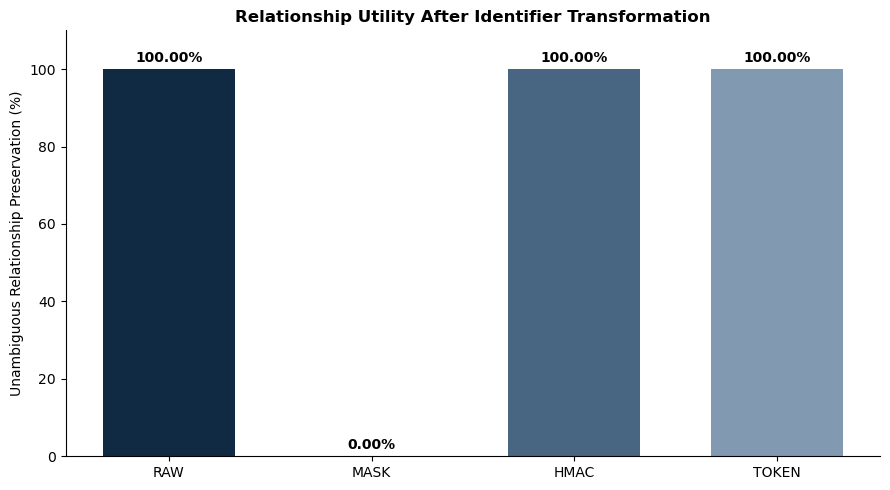

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 01. 순서 지정
order = ["RAW", "MASK", "HMAC", "TOKEN"]

plot_df = (
    utility_summary
    .set_index("scheme")
    .loc[order]
    .reset_index()
)

# 02. 남색 팔레트
colors = [
    "#102A43",
    "#243B53",
    "#486581",
    "#829AB1"
]

# 03. 그래프
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))

bars = ax.bar(
    x,
    plot_df["Unambiguous_Join_Rate"],
    color=colors,
    width=0.65
)

# 04. 값 표시
for bar, value in zip(
    bars,
    plot_df["Unambiguous_Join_Rate"],
    strict=False,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# 05. 축 설정
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scheme"])

ax.set_ylim(0, 110)

ax.set_ylabel(
    "Unambiguous Relationship Preservation (%)"
)

ax.set_title(
    "Relationship Utility After Identifier Transformation",
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# CHAPTER 2-9. Transform별 식별자 충돌 분석

## 목적

관계 Utility 결과에서 MASK가 0%로 나타난 원인을 확인한다.

부분 마스킹은 동일한 끝자리 패턴을 가진 서로 다른 식별자를
동일한 값으로 변환할 수 있다.

따라서 각 Transform에 대해 다음을 비교한다.

- 원본 고유 식별자 수
- 변환 후 고유 식별자 수
- 고유값 보존율
- Collision 발생 그룹 수
- Collision에 영향을 받은 원본 식별자 수
- Collision Rate

In [42]:
# 01. 결과 정렬
collision_summary = (
    identity_result_df[
        [
            "scheme",
            "identifier",
            "raw_unique",
            "transformed_unique",
            "unique_preservation_pct",
            "collision_groups",
            "collision_values",
            "collision_rate_pct"
        ]
    ]
    .sort_values(["identifier", "scheme"])
    .reset_index(drop=True)
)

collision_summary

,scheme,identifier,raw_unique,transformed_unique,unique_preservation_pct,collision_groups,collision_values,collision_rate_pct
0,HMAC,AccountID,1651,1651,100.00,0,0,0.0
1,MASK,AccountID,1651,100,6.06,100,1651,100.0
2,TOKEN,AccountID,1651,1651,100.00,0,0,0.0
3,HMAC,CustomerID,1100,1100,100.00,0,0,0.0
4,MASK,CustomerID,1100,100,9.09,100,1100,100.0
5,TOKEN,CustomerID,1100,1100,100.00,0,0,0.0


In [43]:
# 01. AccountID MASK 매핑
mask_mapping = pd.DataFrame({
    "RAW_AccountID": accounts_base["AccountID"].astype(str),
    "MASK_AccountID": accounts_mask["AccountID"].astype(str)
}).drop_duplicates()

# 02. MASK 값별 원본 ID 개수
collision_counts = (
    mask_mapping
    .groupby("MASK_AccountID")["RAW_AccountID"]
    .nunique()
    .sort_values(ascending=False)
)

# 03. 충돌 발생 MASK만 추출
collision_mask_values = collision_counts[
    collision_counts > 1
]

print("충돌 MASK 그룹 수:", len(collision_mask_values))
print(
    "최대 하나의 MASK에 합쳐진 AccountID 수:",
    collision_mask_values.max()
)

display(collision_mask_values.head(10))

충돌 MASK 그룹 수: 100
최대 하나의 MASK에 합쳐진 AccountID 수: 17


MASK_AccountID
****00    17
****01    17
****02    17
****03    17
****04    17
****05    17
****06    17
****07    17
****08    17
****09    17
Name: RAW_AccountID, dtype: int64

# CHAPTER 2-9. MASK 식별자 충돌 결과

## 분석 결과

AccountID 부분 마스킹 결과 다음과 같은 충돌이 발생하였다.

- 원본 고유 AccountID: **1,651개**
- 변환 후 MASK 값: **100개**
- 고유값 보존율: **6.06%**
- Collision Group: **100개**
- 최대 하나의 MASK 값에 연결된 AccountID: **17개**

예를 들어 다음과 같이 서로 다른 계좌가 동일한 MASK 값으로 변환되었다.

| MASK AccountID | 연결된 원본 AccountID 수 |
|---|---:|
| `****00` | 17 |
| `****01` | 17 |
| `****02` | 17 |
| `****03` | 17 |
| `****04` | 17 |
| `****05` | 17 |

## 해석

부분 마스킹으로 인해 서로 다른 AccountID가 동일한 식별값으로 합쳐졌다.

즉, MASK 값 자체는 데이터 간 JOIN에 사용할 수 있지만
하나의 MASK 값이 최대 17개의 실제 계좌를 동시에 가리키므로
특정 거래가 어느 계좌에 속하는지 고유하게 결정할 수 없다.

따라서 앞선 관계 Utility 분석에서 MASK의
Unambiguous Relationship Preservation이 **0%**로 나타난 것은
단순 JOIN 실패가 아니라 **식별자 충돌에 따른 관계 모호성 증가** 때문이다.

반면 HMAC과 TOKEN은 각각 원본 식별자와 1:1 대응을 유지하여
관계 Utility 100%를 보존하였다.

In [44]:
# 01. Transform별 JOIN Inflation 결과
join_inflation_summary = relationship_result_df[
    [
        "scheme",
        "relationship",
        "child_rows",
        "join_rows",
        "fk_match_rate_pct",
        "unambiguous_join_rate_pct",
        "join_inflation_pct"
    ]
].copy()

join_inflation_summary

,scheme,relationship,child_rows,join_rows,fk_match_rate_pct,unambiguous_join_rate_pct,join_inflation_pct
0,RAW,Customer → Account,1651,1651,100.0,100.0,0.00
1,RAW,Account → Transaction Origin,48510,48510,100.0,100.0,0.00
2,RAW,Account → Transaction Destination,48510,48510,100.0,100.0,0.00
3,RAW,Account → Loan,317,317,100.0,100.0,0.00
4,MASK,Customer → Account,1651,18161,100.0,0.0,1000.00
5,MASK,Account → Transaction Origin,48510,801905,100.0,0.0,1553.07
6,MASK,Account → Transaction Destination,48510,801672,100.0,0.0,1552.59
7,MASK,Account → Loan,317,5254,100.0,0.0,1557.41
8,HMAC,Customer → Account,1651,1651,100.0,100.0,0.00
9,HMAC,Account → Transaction Origin,48510,48510,100.0,100.0,0.00


In [45]:
# 01. MASK 관계 왜곡 확인
mask_join_result = (
    join_inflation_summary[
        join_inflation_summary["scheme"] == "MASK"
    ]
    .reset_index(drop=True)
)

mask_join_result

,scheme,relationship,child_rows,join_rows,fk_match_rate_pct,unambiguous_join_rate_pct,join_inflation_pct
0,MASK,Customer → Account,1651,18161,100.0,0.0,1000.00
1,MASK,Account → Transaction Origin,48510,801905,100.0,0.0,1553.07
2,MASK,Account → Transaction Destination,48510,801672,100.0,0.0,1552.59
3,MASK,Account → Loan,317,5254,100.0,0.0,1557.41


# CHAPTER 2-10. MASK Join Inflation 분석

## 분석 결과

MASK 적용 후 모든 관계에서 FK Match Rate는 100%로 나타났다.

그러나 이는 관계가 정상적으로 보존되었다는 의미가 아니다.
부분 마스킹으로 서로 다른 식별자가 동일한 값으로 합쳐지면서,
하나의 FK가 여러 부모 레코드와 동시에 연결되는 현상이 발생하였다.

| 관계 | 원본 행 수 | MASK JOIN 행 수 | JOIN 증가율 | 약 배수 |
|---|---:|---:|---:|---:|
| Customer → Account | 1,651 | 18,161 | 1,000.00% | 11.00배 |
| Account → Transaction Origin | 48,510 | 801,905 | 1,553.07% | 16.53배 |
| Account → Transaction Destination | 48,510 | 801,672 | 1,552.59% | 16.53배 |
| Account → Loan | 317 | 5,254 | 1,557.41% | 16.57배 |

## 해석

MASK는 FK 값 자체를 동일한 규칙으로 변환했기 때문에
FK Match Rate는 100%로 유지되었다.

그러나 AccountID 1,651개가 100개의 MASK 값으로 압축되면서
하나의 MASK AccountID가 최대 17개의 실제 계좌를 동시에 가리키게 되었다.

그 결과:

- 관계 존재 여부: 100% 유지
- 고유 관계 식별 가능성: 0%
- JOIN 결과: 최대 약 16.57배 증가

즉, MASK는 단순한 FK 존재성은 유지하지만
금융 데이터 분석에 필요한 정확한 고객·계좌·거래 관계는 보존하지 못하였다.

따라서 관계형 금융 데이터에서 Utility는
단순 FK Match Rate만으로 평가할 수 없으며,
Collision, Unambiguous Join, Join Inflation을 함께 검증해야 한다.

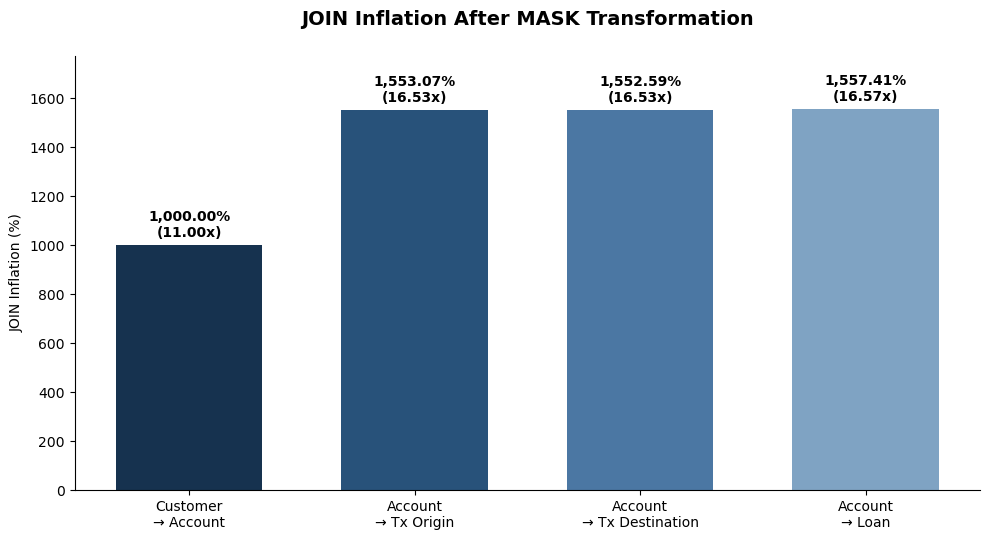

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# 01. MASK 결과 준비
mask_plot = mask_join_result.copy()

mask_plot["join_multiple"] = (
    mask_plot["join_rows"]
    / mask_plot["child_rows"]
)

# 02. 남색 팔레트
colors = [
    "#16324F",
    "#28527A",
    "#4B77A3",
    "#7FA3C3"
]

# 03. 그래프
fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(len(mask_plot))

bars = ax.bar(
    x,
    mask_plot["join_inflation_pct"],
    color=colors,
    width=0.65
)

# 04. 수치 표시
for bar, inflation, multiple in zip(
    bars,
    mask_plot["join_inflation_pct"],
    mask_plot["join_multiple"],
    strict=False,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"{inflation:,.2f}%\n({multiple:.2f}x)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# 05. 축 설정
labels = [
    "Customer\n→ Account",
    "Account\n→ Tx Origin",
    "Account\n→ Tx Destination",
    "Account\n→ Loan"
]

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("JOIN Inflation (%)")

# 06. 제목 및 상단 여백
ax.set_title(
    "JOIN Inflation After MASK Transformation",
    fontsize=14,
    fontweight="bold",
    pad=22
)

ax.set_ylim(
    0,
    mask_plot["join_inflation_pct"].max() * 1.14
)

# 07. 그래프 정리
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# CHAPTER 2-11. Transform Utility 최종 비교

## 목적

RAW / MASK / HMAC / TOKEN의 금융 관계 Utility를 하나의 지표 체계로 비교한다.

최종 비교 지표:

- CustomerID 고유값 보존율
- AccountID 고유값 보존율
- CustomerID Collision Rate
- AccountID Collision Rate
- 관계의 고유 연결 보존율
- 최대 JOIN Inflation

단순히 FK가 연결되는지만 보는 것이 아니라,
변환 이후에도 특정 고객·계좌·거래를 고유하게 식별할 수 있는지를 평가한다.

In [48]:
# 01. RAW 식별자 기준값
raw_identity = pd.DataFrame({
    "scheme": ["RAW"],
    "customer_unique_preservation_pct": [100.0],
    "account_unique_preservation_pct": [100.0],
    "customer_collision_rate_pct": [0.0],
    "account_collision_rate_pct": [0.0]
})

# 02. Transform 식별자 결과
transform_identity = []

for scheme in ["MASK", "HMAC", "TOKEN"]:

    customer_row = identity_result_df[
        (identity_result_df["scheme"] == scheme)
        &
        (identity_result_df["identifier"] == "CustomerID")
    ].iloc[0]

    account_row = identity_result_df[
        (identity_result_df["scheme"] == scheme)
        &
        (identity_result_df["identifier"] == "AccountID")
    ].iloc[0]

    transform_identity.append({
        "scheme": scheme,

        "customer_unique_preservation_pct":
            customer_row["unique_preservation_pct"],

        "account_unique_preservation_pct":
            account_row["unique_preservation_pct"],

        "customer_collision_rate_pct":
            customer_row["collision_rate_pct"],

        "account_collision_rate_pct":
            account_row["collision_rate_pct"]
    })

transform_identity = pd.DataFrame(transform_identity)

identity_final = pd.concat(
    [raw_identity, transform_identity],
    ignore_index=True
)

# 03. 관계 Utility 요약
relationship_final = (
    relationship_result_df
    .groupby("scheme")
    .agg(
        relationship_preservation_pct=(
            "unambiguous_join_rate_pct",
            "mean"
        ),

        max_join_inflation_pct=(
            "join_inflation_pct",
            "max"
        )
    )
    .reset_index()
)

# 04. 최종 결합
final_utility = identity_final.merge(
    relationship_final,
    on="scheme",
    how="left"
)

# 05. 순서 지정
order = ["RAW", "MASK", "HMAC", "TOKEN"]

final_utility["scheme"] = pd.Categorical(
    final_utility["scheme"],
    categories=order,
    ordered=True
)

final_utility = (
    final_utility
    .sort_values("scheme")
    .reset_index(drop=True)
)

final_utility.round(2)

,scheme,customer_unique_preservation_pct,account_unique_preservation_pct,customer_collision_rate_pct,account_collision_rate_pct,relationship_preservation_pct,max_join_inflation_pct
0,RAW,100.00,100.00,0.0,0.0,100.0,0.00
1,MASK,9.09,6.06,100.0,100.0,0.0,1557.41
2,HMAC,100.00,100.00,0.0,0.0,100.0,0.00
3,TOKEN,100.00,100.00,0.0,0.0,100.0,0.00


In [49]:
# 01. Utility Score
final_utility["utility_score"] = (
    final_utility[
        "customer_unique_preservation_pct"
    ] * 0.20
    +
    final_utility[
        "account_unique_preservation_pct"
    ] * 0.30
    +
    final_utility[
        "relationship_preservation_pct"
    ] * 0.50
).round(2)

# 02. 최종 결과
final_utility[
    [
        "scheme",
        "customer_unique_preservation_pct",
        "account_unique_preservation_pct",
        "customer_collision_rate_pct",
        "account_collision_rate_pct",
        "relationship_preservation_pct",
        "max_join_inflation_pct",
        "utility_score"
    ]
]

,scheme,customer_unique_preservation_pct,account_unique_preservation_pct,customer_collision_rate_pct,account_collision_rate_pct,relationship_preservation_pct,max_join_inflation_pct,utility_score
0,RAW,100.00,100.00,0.0,0.0,100.0,0.00,100.00
1,MASK,9.09,6.06,100.0,100.0,0.0,1557.41,3.64
2,HMAC,100.00,100.00,0.0,0.0,100.0,0.00,100.00
3,TOKEN,100.00,100.00,0.0,0.0,100.0,0.00,100.00


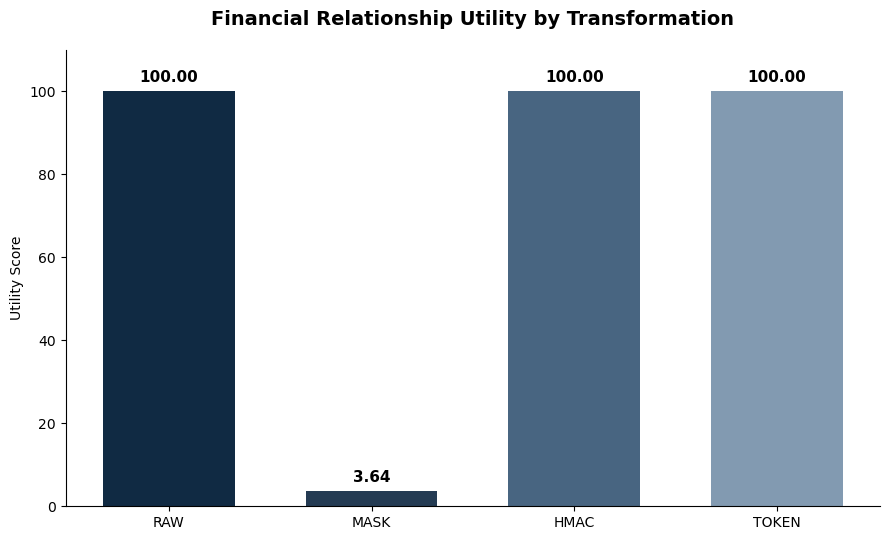

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# 01. 데이터 준비
plot_df = final_utility.copy()

colors = [
    "#102A43",
    "#243B53",
    "#486581",
    "#829AB1"
]

# 02. 그래프
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(plot_df))

bars = ax.bar(
    x,
    plot_df["utility_score"],
    color=colors,
    width=0.65
)

# 03. 값 표시
for bar, value in zip(
    bars,
    plot_df["utility_score"],
    strict=False,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# 04. 축 설정
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scheme"])

ax.set_ylim(0, 110)

ax.set_ylabel("Utility Score")
ax.set_title(
    "Financial Relationship Utility by Transformation",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# CHAPTER 2-12. HMAC vs TOKEN 운영·복원 특성 검증

## 분석 목적

앞선 관계 Utility 분석에서 HMAC과 TOKEN은 모두 관계 보존율 100%를 기록하였다.

그러나 두 방식은 운영 목적이 다르다.

이번 분석에서는 다음을 비교한다.

- 동일 입력에 대한 변환 일관성
- 원문 직접 노출 여부
- TOKEN Vault 기반 복원 정확도
- HMAC Key 변경 시 식별자 연속성
- 관계 추적을 위한 외부 저장소 의존성

## 핵심 질문

> 관계 Utility가 동일하게 100%라면, 어떤 상황에서 HMAC을 사용하고 어떤 상황에서 TOKEN을 사용해야 하는가?

In [51]:
# 01. HMAC 결정성 검증
hmac_test_1 = accounts_base["AccountID"].apply(hmac_id)
hmac_test_2 = accounts_base["AccountID"].apply(hmac_id)

hmac_determinism = (
    hmac_test_1 == hmac_test_2
).mean() * 100

# 02. TOKEN 결정성 검증
token_test_1 = (
    accounts_base["AccountID"]
    .astype(int)
    .map(account_token_vault)
)

token_test_2 = (
    accounts_base["AccountID"]
    .astype(int)
    .map(account_token_vault)
)

token_determinism = (
    token_test_1 == token_test_2
).mean() * 100

print(f"HMAC 동일 변환 재현율 : {hmac_determinism:.2f}%")
print(f"TOKEN 동일 변환 재현율: {token_determinism:.2f}%")


HMAC 동일 변환 재현율 : 100.00%
TOKEN 동일 변환 재현율: 100.00%


In [52]:
# 01. HMAC 원문 동일 여부
hmac_raw_exposure = (
    accounts_hmac["AccountID"].astype(str)
    ==
    accounts_base["AccountID"].astype(str)
).mean() * 100

# 02. TOKEN 원문 동일 여부
token_raw_exposure = (
    accounts_token["AccountID"].astype(str)
    ==
    accounts_base["AccountID"].astype(str)
).mean() * 100

print(f"HMAC 원문 직접 노출률 : {hmac_raw_exposure:.2f}%")
print(f"TOKEN 원문 직접 노출률: {token_raw_exposure:.2f}%")

HMAC 원문 직접 노출률 : 0.00%
TOKEN 원문 직접 노출률: 0.00%


In [53]:
# 01. Reverse Vault 생성
account_reverse_vault = {
    token: account_id
    for account_id, token
    in account_token_vault.items()
}

# 02. TOKEN 복원
restored_account_ids = (
    accounts_token["AccountID"]
    .map(account_reverse_vault)
)

# 03. 원본과 비교
token_restore_accuracy = (
    restored_account_ids.astype(int).to_numpy()
    ==
    accounts_base["AccountID"].astype(int).to_numpy()
).mean() * 100

print(
    f"TOKEN Vault 복원 정확도: "
    f"{token_restore_accuracy:.2f}%"
)

TOKEN Vault 복원 정확도: 100.00%


In [54]:
# 01. 새로운 HMAC Key
NEW_HMAC_SECRET = b"fpg-experiment-new-secret-key"

# 02. 새로운 Key용 함수
def hmac_id_new_key(value):

    if pd.isna(value):
        return value

    value = str(int(value))

    return hmac.new(
        NEW_HMAC_SECRET,
        value.encode("utf-8"),
        hashlib.sha256
    ).hexdigest()[:16]

# 03. 기존 Key와 신규 Key 비교
old_hmac = (
    accounts_base["AccountID"]
    .apply(hmac_id)
)

new_hmac = (
    accounts_base["AccountID"]
    .apply(hmac_id_new_key)
)

# 04. 동일 값 유지율
key_rotation_continuity = (
    old_hmac == new_hmac
).mean() * 100

# 05. 변경률
key_rotation_change_rate = (
    old_hmac != new_hmac
).mean() * 100

print(
    f"Key 변경 후 동일값 유지율: "
    f"{key_rotation_continuity:.2f}%"
)

print(
    f"Key 변경 후 식별자 변경률: "
    f"{key_rotation_change_rate:.2f}%"
)

Key 변경 후 동일값 유지율: 0.00%
Key 변경 후 식별자 변경률: 100.00%


In [55]:
# 01. HMAC / TOKEN 운영 특성 비교
operation_comparison = pd.DataFrame({
    "metric": [
        "Relationship Utility",
        "Collision Rate",
        "Same Input Consistency",
        "Direct RAW Exposure",
        "Original Value Restoration",
        "External Dependency",
        "Identity Continuity Risk"
    ],

    "HMAC": [
        "100%",
        "0%",
        f"{hmac_determinism:.2f}%",
        f"{hmac_raw_exposure:.2f}%",
        "Not directly reversible",
        "Secret Key",
        "Key rotation"
    ],

    "TOKEN": [
        "100%",
        "0%",
        f"{token_determinism:.2f}%",
        f"{token_raw_exposure:.2f}%",
        f"{token_restore_accuracy:.2f}%",
        "Token Vault",
        "Vault lifecycle"
    ]
})

operation_comparison

,metric,HMAC,TOKEN
0,Relationship Utility,100%,100%
1,Collision Rate,0%,0%
2,Same Input Consistency,100.00%,100.00%
3,Direct RAW Exposure,0.00%,0.00%
4,Original Value Restoration,Not directly reversible,100.00%
5,External Dependency,Secret Key,Token Vault
6,Identity Continuity Risk,Key rotation,Vault lifecycle


# CHAPTER 2-12. HMAC / TOKEN 운영 특성 비교 결과

## 실험 결과

| Metric | HMAC | TOKEN |
|---|---:|---:|
| Relationship Utility | 100% | 100% |
| Collision Rate | 0% | 0% |
| Same Input Consistency | 100.00% | 100.00% |
| Direct RAW Exposure | 0.00% | 0.00% |
| Original Value Restoration | 직접 복원 불가 | 100.00% |
| External Dependency | Secret Key | Token Vault |
| Identity Continuity Risk | Key Rotation | Vault Lifecycle |

## 결과 해석

### HMAC

- 관계 Utility **100%**
- Collision **0%**
- 동일 Secret Key에서는 동일 입력이 항상 동일한 값으로 변환됨
- 원본 식별자를 직접 노출하지 않음
- 변환값 자체에서 원본을 직접 복원할 수 없음
- Secret Key가 변경되면 기존 HMAC 값과의 연속성이 깨질 수 있음

따라서 **원본 복원이 필요하지 않으면서 동일 고객·계좌를 지속적으로 비교하거나 JOIN해야 하는 업무**에 적합하다.

### TOKEN

- 관계 Utility **100%**
- Collision **0%**
- 동일 Token Vault를 사용하는 경우 동일 입력의 일관성 **100%**
- 원본 식별자를 직접 노출하지 않음
- Vault를 통해 원본 식별자 **100% 복원 가능**
- Utility와 복원 가능성을 동시에 확보하지만 Vault의 접근통제·보관·폐기 정책이 필요함

따라서 **외부 처리 과정에서는 원본을 숨기되, 승인된 내부 환경에서 다시 원본 식별자로 복원해야 하는 업무**에 적합하다.

## MASK와의 비교

앞선 실험에서 MASK는 AccountID 1,651개를 100개의 값으로 축소하면서 식별자 충돌을 발생시켰다.

그 결과:

- AccountID 고유값 보존율: **6.06%**
- Unambiguous Relationship Preservation: **0%**
- JOIN Inflation: 최대 **1,557.41% (약 16.57배)**

반면 HMAC과 TOKEN은 관계 Utility를 모두 **100% 보존**하였다.

## 최종 해석

본 실험에서는 Transform 방식별 역할을 다음과 같이 구분할 수 있다.

> **MASK → 관계 추적이 필요하지 않은 단순 표시·노출 최소화**

> **HMAC → 복원 없이 동일 객체의 관계 추적·JOIN 필요**

> **TOKEN → 관계 추적과 승인된 원본 복원이 모두 필요**

따라서 Financial Privacy Gateway에서는 하나의 Transform을 일괄 적용하는 것이 아니라,
업무의 관계 유지 필요성과 복원 필요성에 따라 MASK / HMAC / TOKEN을 선택적으로 적용하는 정책 구조가 필요하다.

# CHAPTER 2-13. Privacy × Utility 종합 비교

## 분석 목적

앞선 분석에서는 MASK / HMAC / TOKEN이 금융 관계형 데이터의 Utility를
얼마나 보존하는지 검증하였다.

이번 단계에서는 관계 Utility와 개인정보 노출 특성을 함께 비교하여
각 Transform이 어떤 금융 업무에 적합한지 최종적으로 정리한다.

## 평가 원칙

Privacy를 임의의 단일 점수로 만들지 않는다.

대신 실험에서 직접 확인할 수 있는 다음 지표를 사용한다.

### Utility
- Unambiguous Relationship Preservation
- Collision Rate
- JOIN Inflation

### Privacy
- Direct RAW Exposure
- 원본 복원 가능 여부

### Operational Property
- Secret Key 또는 Token Vault 의존성
- 동일 객체 추적 가능성

따라서 Privacy × Utility 분석은
단순 종합점수보다 각 Transform의 특성과 trade-off를 함께 해석한다.

In [56]:
# 01. 최종 Privacy × Utility 데이터
privacy_utility_final = pd.DataFrame({
    "scheme": [
        "RAW",
        "MASK",
        "HMAC",
        "TOKEN"
    ],

    "relationship_utility_pct": [
        100.00,
        0.00,
        100.00,
        100.00
    ],

    "direct_raw_exposure_pct": [
        100.00,
        0.00,
        0.00,
        0.00
    ],

    "raw_suppression_pct": [
        0.00,
        100.00,
        100.00,
        100.00
    ],

    "reversible": [
        "Yes",
        "No",
        "No",
        "Yes (Vault)"
    ],

    "collision_rate_pct": [
        0.00,
        identity_result_df.loc[
            (identity_result_df["scheme"] == "MASK")
            &
            (identity_result_df["identifier"] == "AccountID"),
            "collision_rate_pct"
        ].iloc[0],
        0.00,
        0.00
    ],

    "max_join_inflation_pct": [
        0.00,
        relationship_result_df.loc[
            relationship_result_df["scheme"] == "MASK",
            "join_inflation_pct"
        ].max(),
        0.00,
        0.00
    ]
})

privacy_utility_final.round(2)

,scheme,relationship_utility_pct,direct_raw_exposure_pct,raw_suppression_pct,reversible,collision_rate_pct,max_join_inflation_pct
0,RAW,100.0,100.0,0.0,Yes,0.0,0.00
1,MASK,0.0,0.0,100.0,No,100.0,1557.41
2,HMAC,100.0,0.0,100.0,No,0.0,0.00
3,TOKEN,100.0,0.0,100.0,Yes (Vault),0.0,0.00


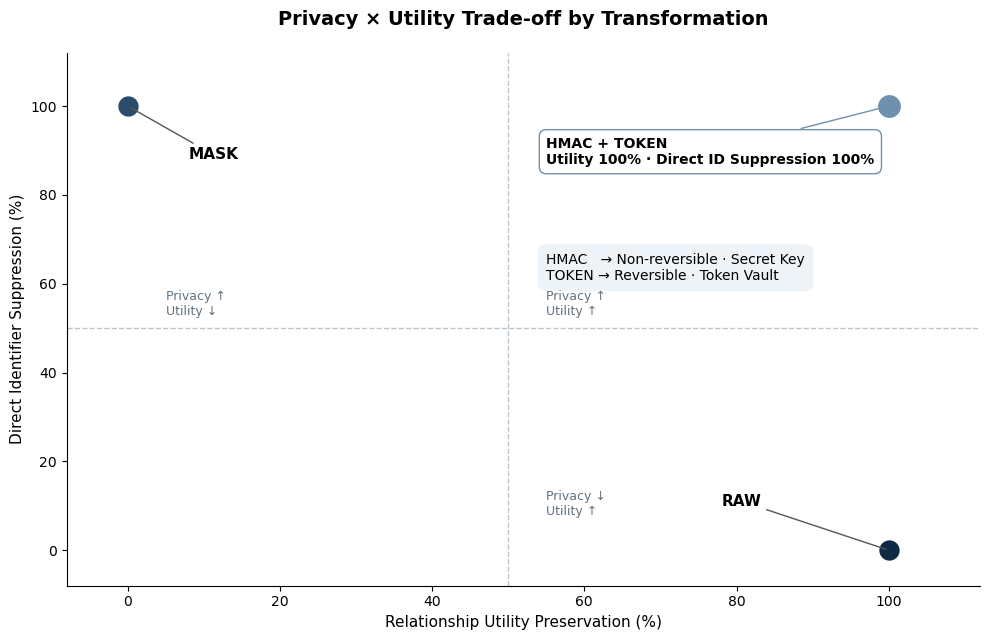

In [58]:
import matplotlib.pyplot as plt

# 01. 그래프 생성
fig, ax = plt.subplots(figsize=(10, 6.5))

# 02. 색상
raw_color = "#102A43"
mask_color = "#294C6B"
shared_color = "#6F91AE"

# 03. 실제 측정 좌표
ax.scatter(
    100, 0,
    s=260,
    color=raw_color,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

ax.scatter(
    0, 100,
    s=260,
    color=mask_color,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# 04. HMAC + TOKEN 동일 좌표
ax.scatter(
    100, 100,
    s=340,
    color=shared_color,
    edgecolor="white",
    linewidth=2,
    zorder=3
)

# 05. RAW 라벨
ax.annotate(
    "RAW",
    xy=(100, 0),
    xytext=(78, 10),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="-",
        color="#555555"
    )
)

# 06. MASK 라벨
ax.annotate(
    "MASK",
    xy=(0, 100),
    xytext=(8, 88),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="-",
        color="#555555"
    )
)

# 07. HMAC / TOKEN 공통 좌표 라벨
ax.annotate(
    "HMAC + TOKEN\nUtility 100% · Direct ID Suppression 100%",
    xy=(100, 100),
    xytext=(55, 87),
    fontsize=10,
    fontweight="bold",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#6F91AE"
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="#6F91AE"
    )
)

# 08. HMAC / TOKEN 차이 표시
ax.text(
    55,
    67,
    "HMAC   → Non-reversible · Secret Key\n"
    "TOKEN → Reversible · Token Vault",
    fontsize=10,
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#EEF3F7",
        edgecolor="none"
    )
)

# 09. 기준선
ax.axvline(
    50,
    linestyle="--",
    linewidth=1,
    color="#AAB7C4",
    alpha=0.8
)

ax.axhline(
    50,
    linestyle="--",
    linewidth=1,
    color="#AAB7C4",
    alpha=0.8
)

# 10. 영역 설명
ax.text(
    5, 53,
    "Privacy ↑\nUtility ↓",
    fontsize=9,
    color="#637381"
)

ax.text(
    55, 53,
    "Privacy ↑\nUtility ↑",
    fontsize=9,
    color="#637381"
)

ax.text(
    55, 8,
    "Privacy ↓\nUtility ↑",
    fontsize=9,
    color="#637381"
)

# 11. 축 설정
ax.set_xlim(-8, 112)
ax.set_ylim(-8, 112)

ax.set_xlabel(
    "Relationship Utility Preservation (%)",
    fontsize=11
)

ax.set_ylabel(
    "Direct Identifier Suppression (%)",
    fontsize=11
)

ax.set_title(
    "Privacy × Utility Trade-off by Transformation",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# 12. 그래프 정리
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# CHAPTER 2-14. 최종 분석 결론

## 1. MASK

MASK는 원본 식별자의 직접 노출을 제거했지만,
AccountID 1,651개가 100개의 MASK 값으로 축소되면서
식별자 충돌이 발생하였다.

그 결과:

- AccountID 고유값 보존율: **6.06%**
- Unambiguous Relationship Preservation: **0%**
- JOIN Inflation: 최대 **1,557.41%**
- 실제 JOIN 결과: 최대 약 **16.57배 증가**

따라서 본 실험의 부분 마스킹 방식은
단순 화면 표시나 외부 노출 최소화에는 사용할 수 있지만,
고객 → 계좌 → 거래 관계를 추적해야 하는 분석에는 적합하지 않았다.

---

## 2. HMAC

HMAC은 원본 식별자를 직접 노출하지 않으면서
동일한 원본에 동일한 변환값을 생성하였다.

실험 결과:

- Relationship Utility: **100%**
- Collision Rate: **0%**
- Direct RAW Exposure: **0%**
- Same Input Consistency: **100%**
- JOIN Inflation: **0%**

따라서 원본 복원이 필요하지 않으면서
고객·계좌·거래의 동일성을 지속적으로 비교하거나 JOIN해야 하는 업무에 적합하다.

다만 Secret Key 변경 시 기존 식별자와의 연속성이 깨질 수 있으므로
Key Lifecycle 관리가 필요하다.

---

## 3. TOKEN

TOKEN 역시 관계 Utility를 100% 유지하면서
원본 식별자를 직접 노출하지 않았다.

실험 결과:

- Relationship Utility: **100%**
- Collision Rate: **0%**
- Direct RAW Exposure: **0%**
- Same Input Consistency: **100%**
- Vault 기반 원본 복원 정확도: **100%**
- JOIN Inflation: **0%**

따라서 외부 처리 단계에서는 식별자를 숨기면서,
승인된 내부 환경에서는 다시 원본으로 복원해야 하는 업무에 적합하다.

대신 Token Vault의 접근권한, 보관, 폐기 및 감사통제가 필요하다.

---

# 최종 결론

본 실험은 금융 관계형 데이터에서 Transform을 선택할 때
단순히 "개인정보를 가렸는가"만 평가해서는 안 된다는 것을 보여준다.

부분 MASK는 직접 식별정보 노출을 줄였지만
식별자 충돌로 인해 금융 데이터 관계 Utility를 크게 훼손하였다.

반면 HMAC과 TOKEN은 원본 식별자를 직접 노출하지 않으면서도
고객 → 계좌 → 거래 → 대출 관계를 100% 보존하였다.

따라서 Financial Privacy Gateway의 Transform 정책은 다음과 같이 구분할 수 있다.

> **MASK**
> 관계 유지가 필요하지 않은 화면 표시 및 최소 노출

> **HMAC**
> 원본 복원 없이 동일 고객·계좌의 관계 추적이 필요한 업무

> **TOKEN**
> 관계 추적과 승인된 원본 복원이 모두 필요한 업무

즉, Financial Privacy Gateway의 핵심은
하나의 변환기법을 일괄 적용하는 것이 아니라,

**업무 목적(Purpose) × 관계 유지 필요성(Utility) × 복원 필요성(Reversibility)**

에 따라 Transform을 선택하는 정책 구조에 있다.

# CHAPTER 2-15. MASK 강도별 Utility 민감도 분석

## 분석 목적

앞선 실험에서 마지막 2자리만 유지하는 MASK는
식별자 충돌로 인해 금융 관계 Utility가 크게 훼손되었다.

그러나 이는 특정 MASK 강도에 따른 결과일 수 있다.

따라서 MASK 강도를 변화시키면서 다음 지표가 어떻게 변하는지 검증한다.

- 고유 식별자 보존율
- Collision Rate
- Unambiguous Relationship Preservation
- JOIN Inflation

비교 조건:

- MASK-2: 마지막 2자리 유지
- MASK-3: 마지막 3자리 유지
- MASK-4: 마지막 4자리 유지

## 핵심 질문

> MASK 강도를 완화하면 관계 Utility는 얼마나 회복되는가?

단, 유지되는 숫자 자릿수가 증가할수록 원본 식별자의 더 많은 구조가
외부에 노출되므로 Utility와 식별정보 최소화 사이의 Trade-off가 존재할 수 있다.

In [59]:
# 01. MASK 함수
def mask_id_k(value, keep_last=2):

    if pd.isna(value):
        return value

    value = str(int(value))

    if keep_last >= len(value):
        return value

    return (
        "*" * (len(value) - keep_last)
        + value[-keep_last:]
    )

In [60]:
# 01. MASK 데이터 생성 함수
def create_mask_dataset(keep_last):

    customers = customers_base.copy()
    accounts = accounts_base.copy()
    transactions = transactions_base.copy()
    loans = loans_base.copy()

    # 02. CustomerID
    customers["CustomerID"] = (
        customers["CustomerID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    accounts["CustomerID"] = (
        accounts["CustomerID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    # 03. AccountID
    accounts["AccountID"] = (
        accounts["AccountID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    transactions["AccountOriginID"] = (
        transactions["AccountOriginID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    transactions["AccountDestinationID"] = (
        transactions["AccountDestinationID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    loans["AccountID"] = (
        loans["AccountID"]
        .apply(lambda x: mask_id_k(x, keep_last))
    )

    return {
        "customers": customers,
        "accounts": accounts,
        "transactions": transactions,
        "loans": loans
    }


# 04. MASK 강도별 생성
mask_variants = {
    "MASK-2": create_mask_dataset(2),
    "MASK-3": create_mask_dataset(3),
    "MASK-4": create_mask_dataset(4)
}

In [61]:
# 01. 식별자 결과
mask_identity_results = []

for scheme, data in mask_variants.items():

    # 02. CustomerID
    customer_result = identity_utility(
        customers_base["CustomerID"],
        data["customers"]["CustomerID"]
    )

    customer_result["scheme"] = scheme
    customer_result["identifier"] = "CustomerID"

    mask_identity_results.append(customer_result)

    # 03. AccountID
    account_result = identity_utility(
        accounts_base["AccountID"],
        data["accounts"]["AccountID"]
    )

    account_result["scheme"] = scheme
    account_result["identifier"] = "AccountID"

    mask_identity_results.append(account_result)


mask_identity_df = pd.DataFrame(
    mask_identity_results
)

mask_identity_df[
    [
        "scheme",
        "identifier",
        "raw_unique",
        "transformed_unique",
        "unique_preservation_pct",
        "collision_groups",
        "collision_values",
        "collision_rate_pct"
    ]
]

,scheme,identifier,raw_unique,transformed_unique,unique_preservation_pct,collision_groups,collision_values,collision_rate_pct
0,MASK-2,CustomerID,1100,100,9.09,100,1100,100.00
1,MASK-2,AccountID,1651,100,6.06,100,1651,100.00
2,MASK-3,CustomerID,1100,1000,90.91,100,200,18.18
3,MASK-3,AccountID,1651,1000,60.57,651,1302,78.86
4,MASK-4,CustomerID,1100,1100,100.00,0,0,0.00
5,MASK-4,AccountID,1651,1651,100.00,0,0,0.00


In [62]:
# 01. 관계 결과
mask_relationship_results = []

for scheme, data in mask_variants.items():

    for (
        relationship,
        parent_table,
        child_table,
        parent_key,
        child_key
    ) in relationships:

        result = relationship_utility(
            data[parent_table],
            data[child_table],
            parent_key,
            child_key
        )

        result["scheme"] = scheme
        result["relationship"] = relationship

        mask_relationship_results.append(result)


mask_relationship_df = pd.DataFrame(
    mask_relationship_results
)

mask_relationship_df[
    [
        "scheme",
        "relationship",
        "fk_match_rate_pct",
        "unambiguous_join_rate_pct",
        "join_inflation_pct"
    ]
]

,scheme,relationship,fk_match_rate_pct,unambiguous_join_rate_pct,join_inflation_pct
0,MASK-2,Customer → Account,100.0,0.00,1000.00
1,MASK-2,Account → Transaction Origin,100.0,0.00,1553.07
2,MASK-2,Account → Transaction Destination,100.0,0.00,1552.59
3,MASK-2,Account → Loan,100.0,0.00,1557.41
4,MASK-3,Customer → Account,100.0,83.28,16.72
5,MASK-3,Account → Transaction Origin,100.0,21.25,78.75
6,MASK-3,Account → Transaction Destination,100.0,21.07,78.93
7,MASK-3,Account → Loan,100.0,19.56,80.44
8,MASK-4,Customer → Account,100.0,100.00,0.00
9,MASK-4,Account → Transaction Origin,100.0,100.00,0.00


In [63]:
# 01. AccountID 지표
account_mask_summary = (
    mask_identity_df[
        mask_identity_df["identifier"] == "AccountID"
    ][
        [
            "scheme",
            "unique_preservation_pct",
            "collision_rate_pct"
        ]
    ]
    .copy()
)

# 02. 관계 평균 및 최대 왜곡
relationship_mask_summary = (
    mask_relationship_df
    .groupby("scheme")
    .agg(
        avg_relationship_preservation_pct=(
            "unambiguous_join_rate_pct",
            "mean"
        ),
        max_join_inflation_pct=(
            "join_inflation_pct",
            "max"
        )
    )
    .reset_index()
)

# 03. 결합
mask_sensitivity_summary = (
    account_mask_summary
    .merge(
        relationship_mask_summary,
        on="scheme"
    )
)

# 04. 유지 자릿수
mask_sensitivity_summary["digits_retained"] = (
    mask_sensitivity_summary["scheme"]
    .str.extract(r"(\d+)")
    .astype(int)
)

mask_sensitivity_summary = (
    mask_sensitivity_summary
    .sort_values("digits_retained")
    .reset_index(drop=True)
)

mask_sensitivity_summary.round(2)

,scheme,unique_preservation_pct,collision_rate_pct,avg_relationship_preservation_pct,max_join_inflation_pct,digits_retained
0,MASK-2,6.06,100.00,0.00,1557.41,2
1,MASK-3,60.57,78.86,36.29,80.44,3
2,MASK-4,100.00,0.00,100.00,0.00,4


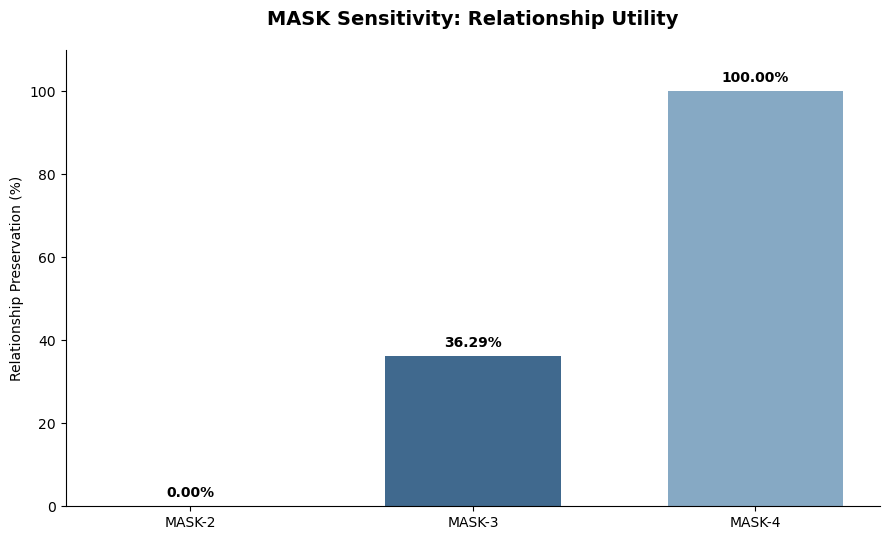

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# 01. 데이터
plot_df = mask_sensitivity_summary.copy()

x = np.arange(len(plot_df))

colors = [
    "#173B63",
    "#40698E",
    "#86A9C4"
]

# 02. 그래프
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    x,
    plot_df["avg_relationship_preservation_pct"],
    color=colors,
    width=0.62
)

# 03. 값 표시
for bar, value in zip(
    bars,
    plot_df["avg_relationship_preservation_pct"],
    strict=False,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# 04. 축
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scheme"])

ax.set_ylim(0, 110)

ax.set_ylabel(
    "Relationship Preservation (%)"
)

ax.set_title(
    "MASK Sensitivity: Relationship Utility",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

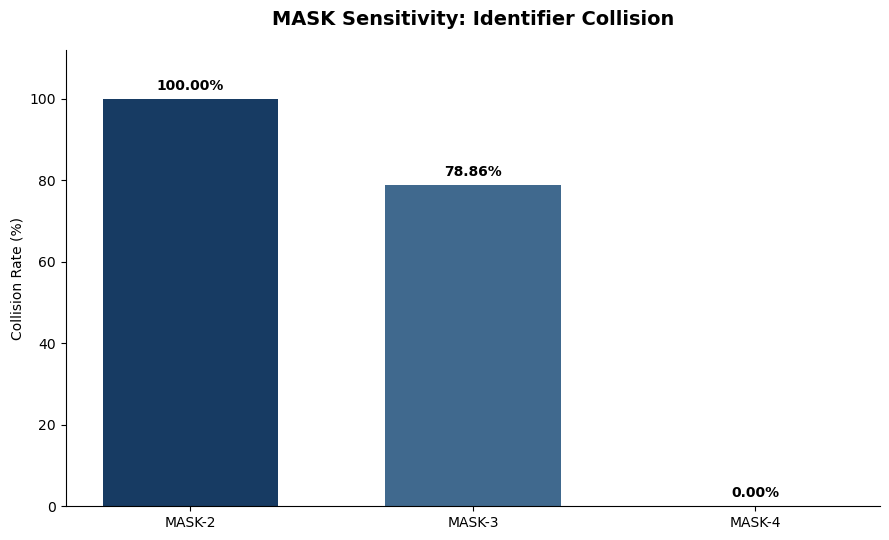

In [65]:
# 01. 그래프
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    x,
    plot_df["collision_rate_pct"],
    color=colors,
    width=0.62
)

# 02. 값 표시
for bar, value in zip(
    bars,
    plot_df["collision_rate_pct"],
    strict=False,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# 03. 축
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scheme"])

ax.set_ylim(
    0,
    max(
        105,
        plot_df["collision_rate_pct"].max() * 1.12
    )
)

ax.set_ylabel("Collision Rate (%)")

ax.set_title(
    "MASK Sensitivity: Identifier Collision",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# CHAPTER 2-15. MASK 민감도 분석 — Privacy × Utility Trade-off

## 1. 분석 목적

MASK는 식별자의 일부를 남기고 일부를 가리는 방식이다.

따라서 **얼마나 많이 가리느냐에 따라 Privacy와 Utility가 동시에 달라진다.**

이번 분석에서는 AccountID의 마지막 자릿수를 각각 2자리, 3자리, 4자리 유지하여
MASK 강도 변화에 따른 관계 Utility를 비교하였다.

---

## 2. 분석 결과

| MASK 방식 | 유지 자릿수 | Collision Rate | Relationship Preservation | 해석 |
|---|---:|---:|---:|---|
| **MASK-2** | 마지막 2자리 | **100.00%** | **0.00%** | Privacy 강함 / Utility 거의 없음 |
| **MASK-3** | 마지막 3자리 | **78.86%** | **36.29%** | Privacy와 Utility 중간 |
| **MASK-4** | 마지막 4자리 | **0.00%** | **100.00%** | Utility 높음 / Privacy 약해짐 |

---

## 3. MASK-2

6자리 AccountID 중 마지막 **2자리만 유지**하였다.

예:

> `200094 → ****94`

마지막 2자리만 남기면서 서로 다른 계좌들이 동일한 MASK 값으로 합쳐졌다.

### 결과

- Collision Rate: **100.00%**
- Relationship Preservation: **0.00%**

### 해석

식별정보를 강하게 가리기 때문에 **Privacy는 가장 강하다.**

그러나 계좌 간 구분이 불가능해져
고객 → 계좌 → 거래 관계를 정확하게 추적할 수 없다.

> **MASK-2 = Privacy 강함 / Utility 거의 없음**

---

## 4. MASK-3

6자리 AccountID 중 마지막 **3자리를 유지**하였다.

예:

> `200094 → ***094`

MASK-2보다 더 많은 정보를 남기면서 계좌 구분 능력이 일부 회복되었다.

### 결과

- Collision Rate: **78.86%**
- Relationship Preservation: **36.29%**

### 해석

MASK-2보다 관계 Utility는 개선되지만,
여전히 다수의 AccountID가 동일한 MASK 값으로 충돌한다.

따라서 정확한 금융 관계 분석에는 부족하다.

> **MASK-3 = Privacy와 Utility의 중간 영역**

---

## 5. MASK-4

6자리 AccountID 중 마지막 **4자리를 유지**하였다.

예:

> `200094 → **0094`

4자리까지 공개하면서 본 데이터에서는 서로 다른 AccountID를 충분히 구분할 수 있게 되었다.

### 결과

- Collision Rate: **0.00%**
- Relationship Preservation: **100.00%**

### 해석

관계 Utility는 완전히 회복되었다.

그러나 이것은 MASK 자체의 성능이 좋아진 것이 아니라,
**원본 식별자의 6자리 중 4자리를 그대로 노출했기 때문에 계좌 구분이 가능해진 결과**이다.

즉, Utility를 높이기 위해 Privacy를 상당 부분 포기한 것이다.

> **MASK-4 = Utility 높음 / Privacy 약함**

---

# 6. 핵심 Trade-off

MASK 강도가 강할수록:

> **Privacy ↑ / Utility ↓**

MASK 강도를 완화할수록:

> **Privacy ↓ / Utility ↑**

이를 이번 실험 결과로 정리하면 다음과 같다.

```text
MASK-2
Privacy  ██████████
Utility

MASK-3
Privacy  ███████
Utility  ████

MASK-4
Privacy  ███
Utility  ██████████

In [ ]:
#업무 목적 + 관계 유지 필요성 + 복원 필요성 + 허용 가능한 노출 수준